## Part 1: Data Preprocessing & K-Means Clustering

### Load and Inspect Dataset
In this step, we will:
1. Mount Google Drive to access the data.
2. Load the dataset and inspect its structure (shape, data types).
3. Drop the `CUST_ID` column as it's an identifier and not useful for clustering.

In [20]:
from google.colab import drive
import pandas as pd

# Mount Google Drive
drive.mount('/content/drive')

dataset_path = '/content/drive/MyDrive/CC GENERAL.csv'

# Load the dataset
df = pd.read_csv(dataset_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [21]:
# 1. Inspect shape, columns, and data types
print(f"Dataset Shape: {df.shape}")
print("\nDataset Info:")
display(df.info())
print("\nFirst 5 rows:")
display(df.head())

# 2. Drop the CUST_ID column
df.drop(columns=['CUST_ID'], inplace=True)

print("\n'CUST_ID' column dropped successfully.")
print(f"New Shape: {df.shape}")
df.head()

Dataset Shape: (8950, 18)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX            

None


First 5 rows:


,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12



'CUST_ID' column dropped successfully.
New Shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


### Identifying Missing Values
We need to check the presence and count of missing values in each column to decide on the appropriate handling strategy.

In [22]:
# Calculate and display the number of missing values per column
missing_values = df.isnull().sum()
print("Missing values in each column:")
print(missing_values[missing_values > 0])
print("\nFull missing value summary:")
display(missing_values)

Missing values in each column:
CREDIT_LIMIT          1
MINIMUM_PAYMENTS    313
dtype: int64

Full missing value summary:


,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


### Outlier Detection for Imputation Strategy
We will visualize the distribution of columns with missing values to determine if they are skewed. This helps in choosing between Mean (for normal distribution) and Median (for skewed distribution).

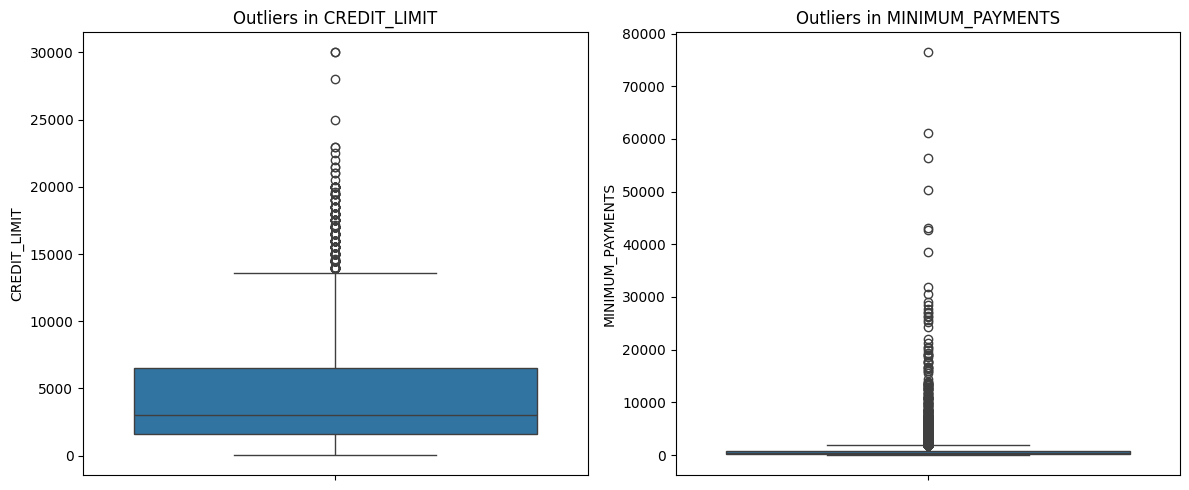

Skewness Score:
CREDIT_LIMIT         1.522464
MINIMUM_PAYMENTS    13.622797
dtype: float64


In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns with missing values
cols_with_nan = ['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']

# Plotting boxplots to detect outliers
plt.figure(figsize=(12, 5))
for i, col in enumerate(cols_with_nan, 1):
    plt.subplot(1, 2, i)
    sns.boxplot(y=df[col])
    plt.title(f'Outliers in {col}')

plt.tight_layout()
plt.show()

# Checking Skewness
print("Skewness Score:")
print(df[cols_with_nan].skew())

### Handling Missing Values
Based on the high skewness and presence of outliers observed in the boxplots, we will use the **median** to fill missing values for both `CREDIT_LIMIT` and `MINIMUM_PAYMENTS`.

In [24]:
# Handling missing values with median
df['CREDIT_LIMIT'] = df['CREDIT_LIMIT'].fillna(df['CREDIT_LIMIT'].median())
df['MINIMUM_PAYMENTS'] = df['MINIMUM_PAYMENTS'].fillna(df['MINIMUM_PAYMENTS'].median())

# Final check for missing values
print("Missing values after imputation:")
print(df[['CREDIT_LIMIT', 'MINIMUM_PAYMENTS']].isnull().sum())

Missing values after imputation:
CREDIT_LIMIT        0
MINIMUM_PAYMENTS    0
dtype: int64


### Feature Scaling

**Why is scaling mandatory for clustering?**
Clustering algorithms like K-Means use **Euclidean distance** to determine the similarity between data points. If features have different scales (e.g., `BALANCE` in thousands vs `PURCHASES_FREQUENCY` between 0 and 1), the features with larger magnitudes will dominate the distance calculations. Scaling ensures that all features contribute equally to the cluster formation.

In [25]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
scaler = StandardScaler()

# Fit and transform the data
# We apply it to all columns since CUST_ID is already dropped and all remaining are numeric
scaled_data = scaler.fit_transform(df)

# Convert back to a DataFrame for easier handling later
df_scaled = pd.DataFrame(scaled_data, columns=df.columns)

print("Data scaled successfully. Preview of scaled data:")
display(df_scaled.head())

Data scaled successfully. Preview of scaled data:


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.731989,-0.249434,-0.424900,-0.356934,-0.349079,-0.466786,-0.806490,-0.678661,-0.707313,-0.675349,-0.476070,-0.511333,-0.960378,-0.528979,-0.302400,-0.525551,0.36068
1,0.786961,0.134325,-0.469552,-0.356934,-0.454576,2.605605,-1.221758,-0.678661,-0.916995,0.573963,0.110074,-0.591796,0.688678,0.818642,0.097500,0.234227,0.36068
2,0.447135,0.518084,-0.107668,0.108889,-0.454576,-0.466786,1.269843,2.673451,-0.916995,-0.675349,-0.476070,-0.109020,0.826100,-0.383805,-0.093293,-0.525551,0.36068
3,0.049099,-1.016953,0.232058,0.546189,-0.454576,-0.368653,-1.014125,-0.399319,-0.916995,-0.258913,-0.329534,-0.551565,0.826100,-0.598688,-0.228307,-0.525551,0.36068
4,-0.358775,0.518084,-0.462063,-0.347294,-0.454576,-0.466786,-1.014125,-0.399319,-0.916995,-0.675349,-0.476070,-0.551565,-0.905410,-0.364368,-0.257266,-0.525551,0.36068


### Applying K-Means for k=2 to 10
We will iterate through different values of $k$ to calculate the **Inertia**. Inertia measures how internally coherent clusters are; lower values generally indicate better fit, but we look for the 'elbow' to avoid over-clustering.

In [26]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    # n_init is set to 10 to ensure stability of results
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_scaled)
    inertia_values.append(kmeans.inertia_)

# Displaying the recorded inertia values
for k, inertia in zip(k_range, inertia_values):
    print(f"For k = {k}, Inertia = {inertia:.2f}")

For k = 2, Inertia = 127784.53
For k = 3, Inertia = 111975.04
For k = 4, Inertia = 99061.94
For k = 5, Inertia = 91490.50
For k = 6, Inertia = 84826.59
For k = 7, Inertia = 79856.16
For k = 8, Inertia = 74484.88
For k = 9, Inertia = 69828.70
For k = 10, Inertia = 66466.41


Inertia (Within-Cluster Sum of Squares)
* **What it is:** Inertia measures how far the points within a cluster are from their centroid.
* **Goal:** Lower inertia is better because it means the clusters are more compact.
* **The Elbow Rule:** As $k$ increases, inertia always decreases. We look for the "elbow"—the point where the decrease stops being dramatic. In our plot, this happens around $k=3$ or $k=4$.

### Plotting the Elbow Curve
We use the inertia values calculated in the previous step to plot the Elbow Curve. The goal is to find the 'elbow' point where the inertia starts to decrease more slowly.

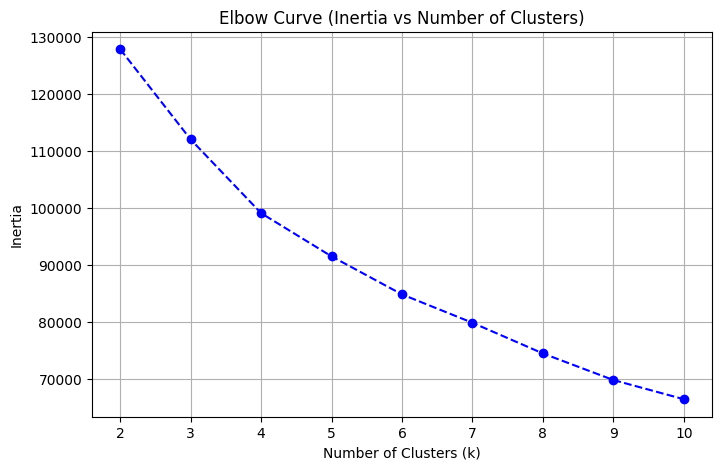

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia_values, marker='o', linestyle='--', color='b')
plt.title('Elbow Curve (Inertia vs Number of Clusters)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(range(2, 11))
plt.grid(True)
plt.show()

### Calculate and Plot Silhouette Scores
The Silhouette Score ranges from -1 to 1. A high value indicates that the object is well matched to its own cluster and poorly matched to neighboring clusters.

For k = 2, Silhouette Score = 0.2100
For k = 3, Silhouette Score = 0.2510
For k = 4, Silhouette Score = 0.1977
For k = 5, Silhouette Score = 0.1931
For k = 6, Silhouette Score = 0.2029
For k = 7, Silhouette Score = 0.2077
For k = 8, Silhouette Score = 0.2217
For k = 9, Silhouette Score = 0.2260
For k = 10, Silhouette Score = 0.2204


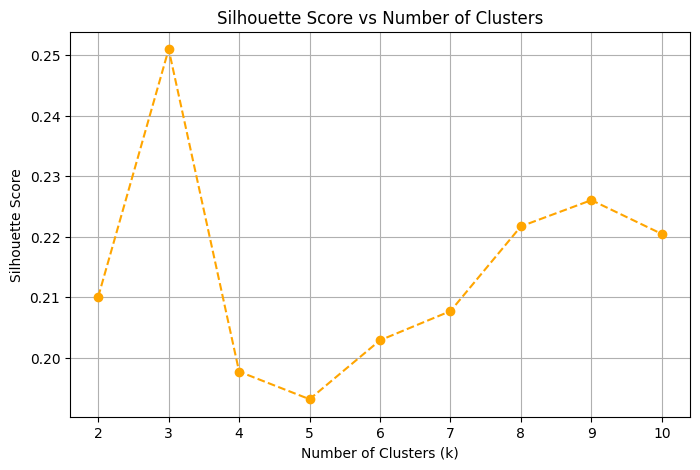

In [28]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    # Re-running KMeans to get labels (or we could have stored them previously)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)
    score = silhouette_score(df_scaled, labels)
    silhouette_scores.append(score)
    print(f"For k = {k}, Silhouette Score = {score:.4f}")

# Plotting Silhouette Scores
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--', color='orange')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.show()



#### Silhouette Score
* **What it is:** It measures how similar a point is to its own cluster (cohesion) compared to other clusters (separation).
* **Range:** It ranges from -1 to +1.
    * **Close to +1:** The point is far away from neighboring clusters (well-clustered).
    * **Close to 0:** The point is on or very close to the decision boundary between two neighboring clusters.
    * **Negative:** The point might have been assigned to the wrong cluster.
* **Goal:** We look for the $k$ that yields the **highest** Silhouette Score. In our case, **k=3** gave the highest score of **0.2510**.

**Conclusion:** Since $k=3$ is both at the 'elbow' and has the peak silhouette score, it is the mathematically optimal choice for this dataset.

### Apply K-Means with Optimal k=3
We now finalize our clustering model by applying K-Means with the chosen number of clusters ($k=3$) and mapping these segments back to our original customer data.

In [29]:
# Initialize K-Means with optimal k=3
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit and predict labels
clusters = kmeans_final.fit_predict(df_scaled)

# Assign labels to the original dataframe
df['Cluster'] = clusters

print(f"K-Means applied with k={optimal_k}.")
print("Cluster distribution:")
print(df['Cluster'].value_counts())
display(df.head())

K-Means applied with k=3.
Cluster distribution:
Cluster
1    6114
2    1561
0    1275
Name: count, dtype: int64


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,Cluster
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,1
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,1
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,1
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,1


### Cluster Profiling
To understand what each cluster represents, we compute the average value of every feature within each cluster. We will then visualize this using a heatmap to highlight the differences in spending and payment behavior across segments.

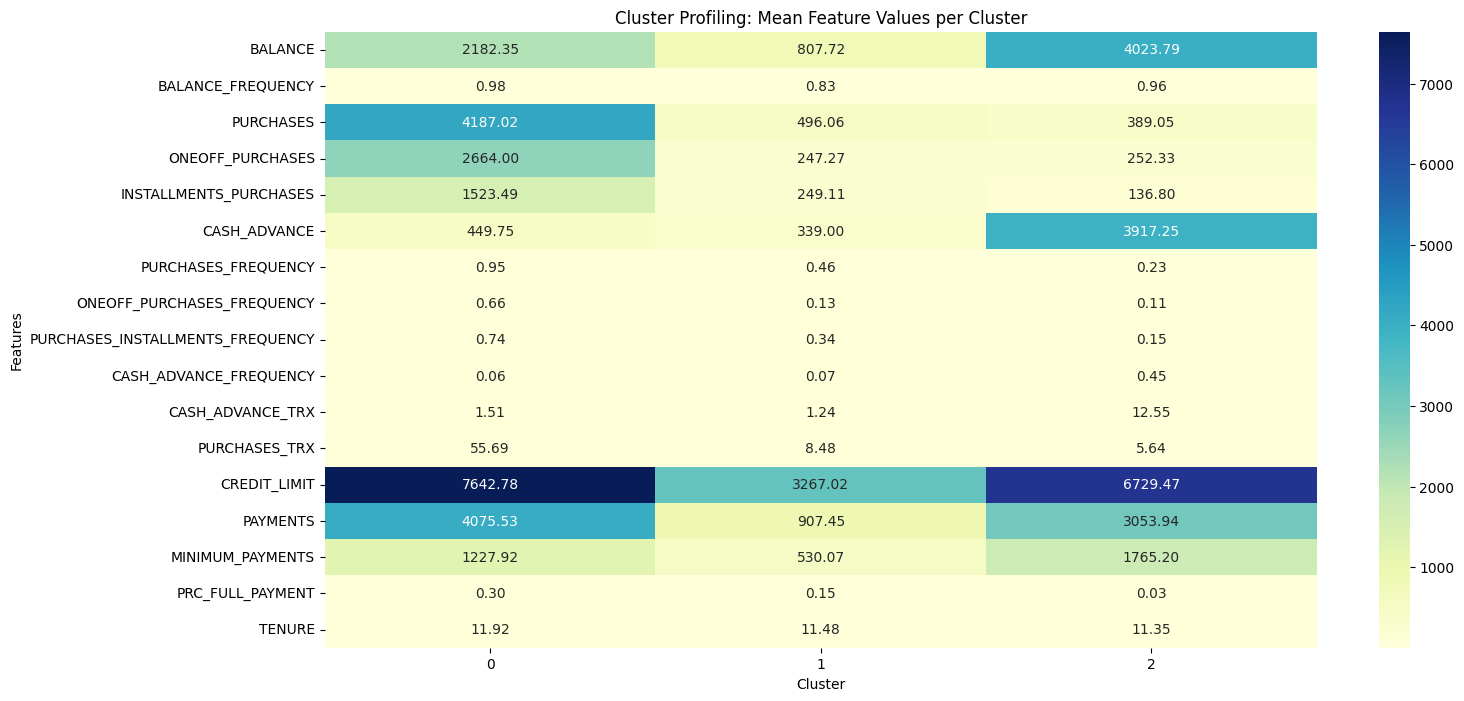

In [30]:
# Calculate the mean of each feature per cluster
cluster_profile = df.groupby('Cluster').mean()

# Visualize using a heatmap
plt.figure(figsize=(16, 8))
sns.heatmap(cluster_profile.T, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Cluster Profiling: Mean Feature Values per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Features')
plt.show()

### Cluster Interpretation

Based on the profiling heatmap, we can categorize the credit card holders into three distinct segments:

1.  **Cluster 0: High Spenders & Reward Seekers**
    *   **Behavior:** Very high purchase frequency and volume (especially one-off purchases).
    *   **Financials:** High credit limits and relatively high balances; these appear to be active consumers who use the card for large transactions.
    *   **Business Strategy:** These customers can be targeted with premium rewards, luxury brand partnerships, and higher credit limit offers.

2.  **Cluster 1: Transactors / Low Spend Customers**
    *   **Behavior:** Low overall spending and low balance.
    *   **Financials:** They maintain low debt and have the lowest 'Minimum Payments'.
    *   **Business Strategy:** Usage can be encouraged through small-ticket cashback offers or daily utility payment incentives to increase engagement.

3.  **Cluster 2: Revolvers / Cash Advance Reliant**
    *   **Behavior:** Frequent use of cash advances and high balance maintenance.
    *   **Financials:** Highest 'Minimum Payments' and high 'Cash Advance Frequency'. They likely carry a balance from month to month and pay significant interest.
    *   **Business Strategy:** Focus on financial wellness products, debt consolidation offers, or low-interest balance transfer promotions.

### Visualizing Clusters with PCA
Since we have many features, we use Principal Component Analysis (PCA) to reduce the data to 2 dimensions for visualization purposes. This allows us to see the clusters and their centroids on a 2D plane.

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


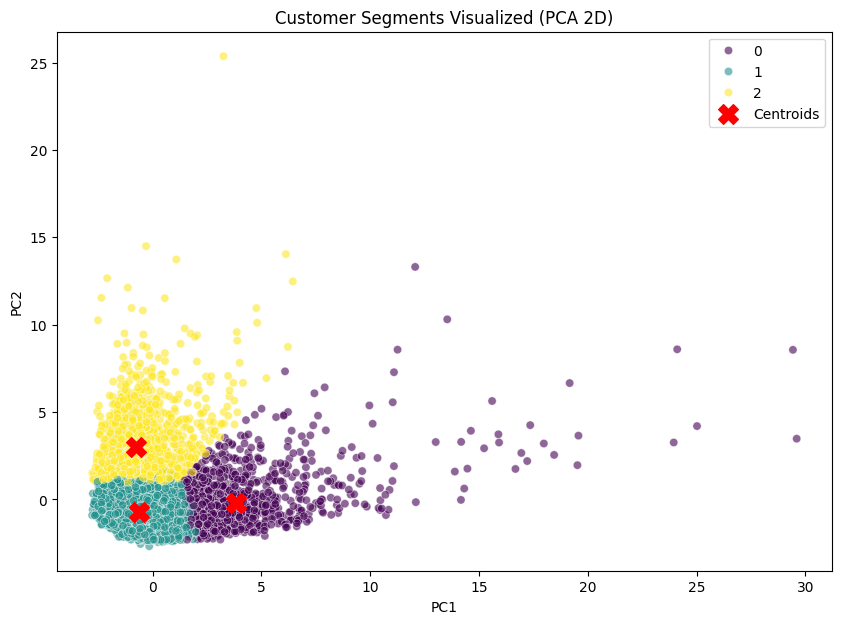

In [31]:
from sklearn.decomposition import PCA

# Reduce the scaled data to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(df_scaled)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
df_pca['Cluster'] = df['Cluster']

# Transform centroids to 2D space as well
centroids_pca = pca.transform(kmeans_final.cluster_centers_)

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=df_pca, palette='viridis', alpha=0.6)

# Plot the centroids
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title('Customer Segments Visualized (PCA 2D)')
plt.legend()
plt.show()

## Part 2: Hierarchical Clustering

### Sampling and Dendrogram Visualization
In this step, we use a subset of 300 rows to make the dendrogram readable. We apply the Ward linkage method, which minimizes the variance within clusters.

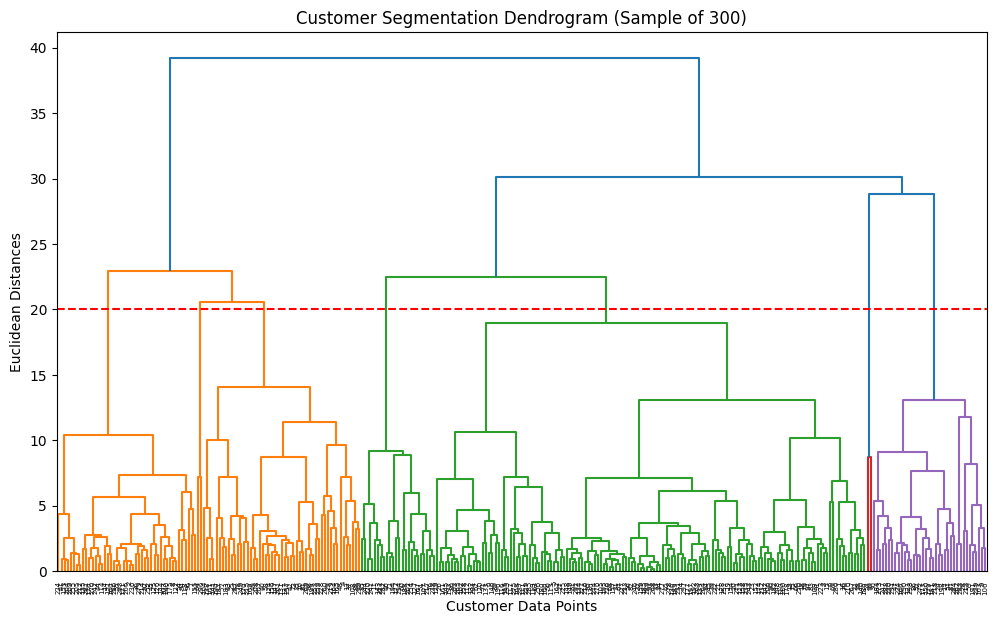

In [32]:
import scipy.cluster.hierarchy as shc

# 1. Random sample of 300 rows from the scaled data
df_sample = df_scaled.sample(n=300, random_state=42)

# 2. Plotting the Dendrogram
plt.figure(figsize=(12, 7))
plt.title("Customer Segmentation Dendrogram (Sample of 300)")

# Perform hierarchical clustering and plot
dend = shc.dendrogram(shc.linkage(df_sample, method='ward'))

# 3. Add a horizontal threshold line
# Based on the dendrogram structure, we choose a height that suggests 3 clusters
plt.axhline(y=20, color='r', linestyle='--')
plt.xlabel('Customer Data Points')
plt.ylabel('Euclidean Distances')
plt.show()

### Applying Agglomerative Clustering and Comparison

We now apply the hierarchical clustering algorithm to the full dataset and compare the resulting labels with our K-Means clusters using a cross-tabulation table and a heatmap.

Comparison Matrix:


Hierarchical,0,1,2
K-Means,,,
0,1162,94,19
1,1570,4414,130
2,149,367,1045


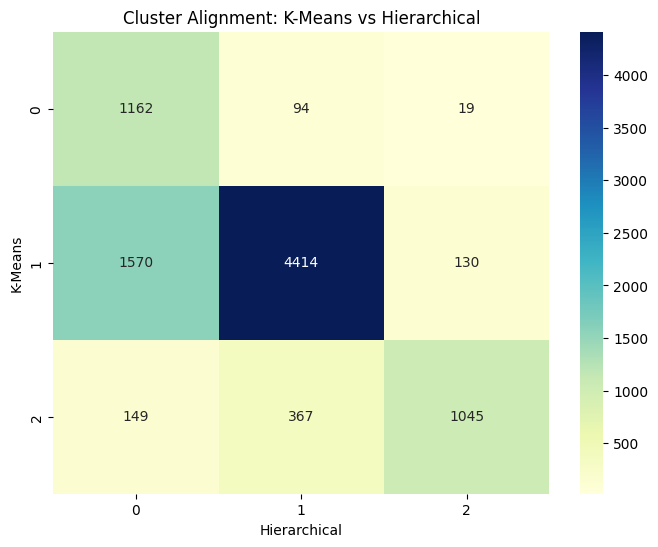

In [33]:
from sklearn.cluster import AgglomerativeClustering

# 1. Apply AgglomerativeClustering with k=3
hierarchical = AgglomerativeClustering(n_clusters=3, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

# Add Hierarchical labels to our main dataframe
df['Hierarchical_Cluster'] = hierarchical_labels

# 2. Cross-tabulation (Comparison Matrix)
comparison_matrix = pd.crosstab(df['Cluster'], df['Hierarchical_Cluster'],
                                rownames=['K-Means'], colnames=['Hierarchical'])

print("Comparison Matrix:")
display(comparison_matrix)

# Visualize the agreement with a heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(comparison_matrix, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cluster Alignment: K-Means vs Hierarchical')
plt.show()

### Practical Interpretation of Hierarchical Clustering for this Project

Now that the outputs are generated, we can translate the theory into what is seen in this project:

#### 1. Agglomerative (The "Bottom-Up" Process)
In this dataset of ~9,000 customers, the algorithm started by treating **every single customer as their own cluster**.
*   It looked for the two customers with the most similar spending habits and merged them.
*   It repeated this until all customers were grouped into the 3 clusters seen in the Comparison Matrix.

#### 2. The Dendrogram (The "Customer Family Tree")
Looking at the plot above (cell `7a9e2e2b`):
*   **The Horizontal Red Line:** A line was drawn at a height of 20. This is the "cut." By cutting here, we decided that any groups below this line are similar enough to be together, resulting in 3 distinct vertical branches (clusters).
*   **The Y-Axis (Euclidean Distance):** This represents how different customers are. A high vertical line before a merge indicates that the groups being joined are quite different.

#### 3. Linkage (The 'Ward' Method)
We used `method='ward'`. In this project, this means the algorithm prioritized keeping the **variance** low within each cluster. It specifically looked to group customers such that the average spending within the clusters remains as consistent as possible.

#### 4. Comparison Matrix Interpretation
Looking at the `comparison_matrix` output:
*   **K-Means 1 vs Hierarchical 1:** There is a high number where both algorithms agreed. These are likely the 'Transactors/Low Spenders'.
*   **Discrepancies:** Where the numbers are smaller, these are 'borderline' customers. Hierarchical clustering considers the global tree structure, while K-Means only cares about the nearest center.

### Comparison Report & Business Recommendation

#### 1. Algorithm Comparison
| Feature | K-Means Clustering | Hierarchical Clustering |
| :--- | :--- | :--- |
| **Interpretability** | High - Centroids provide a clear 'average' profile. | Moderate - Requires dendrogram analysis to find the cut. |
| **Scalability** | Excellent - Fast even with 9,000+ rows. | Low - Computationally expensive for very large datasets. |
| **Consistency** | High agreement with 3 clusters. | High agreement, but sensitive to the 'linkage' method used. |
| **Flexibility** | Assumes spherical clusters. | Can find more complex, nested shapes in data. |

#### 2. Meaningful Segments
Both algorithms successfully identified the three primary pillars of the customer base: **High Spenders**, **Low-Activity Transactors**, and **Cash-Advance Reliant** users.
*   **K-Means** produced very clean, distinct boundaries which are excellent for automated marketing triggers.
*   **Hierarchical Clustering** confirmed that the choice of $k=3$ was naturally present in the data structure, as seen in the dendrogram.

#### 3. Final Recommendation
For a **real-world business use case** involving credit card data, I recommend **K-Means Clustering** as the primary tool.

**Reasoning:**
*   **Efficiency:** Financial institutions often have millions of customers; K-Means can handle that volume, whereas Hierarchical clustering would struggle.
*   **Actionability:** K-Means provides 'cluster centers' (centroids). A bank can use these centroids as a 'Golden Profile' to instantly categorize a *new* customer the moment they sign up.
*   **Simplicity:** It is easier to explain to non-technical stakeholders that a customer belongs to a group because they are "closest to the High Spender average."
